# Bank of America — Financial Forecasting
## Week 2 | Preyash Gandhi

### Objective
Build a simple forecast of Bank of America's closing stock price
using the cleaned Week 1 dataset.

### Data and Evaluation
- Dataset: 13,329 records from 21 February 1973 to 31 December 2025.
- Training: 13,269 records, ending 6 October 2025.
- Testing: Last 60 trading sessions, from 7 October to 31 December 2025.
- Metrics: Mean Absolute Error (MAE) and Root Mean Squared Error (RMSE).

### Forecasting Methods
1. Naive: Use the last training closing price for all 60 test sessions.
2. 20-Session Average: Use the mean of the last 20 training closing prices
   for all 60 test sessions.

The 20-session window represents roughly one trading month and gives
equal weight to recent observations. Both forecasts remain fixed
throughout the test period, without using test prices to update them.

### Forecast Beyond the Dataset
Use the last 20 closing prices available on 31 December 2025
to forecast the next 60 trading sessions.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("Bank_of_America_Cleaned.csv")

df.head()

,Date,Open,High,Low,Close,Volume,ticker,name,Zero_Volume_Flag,Year,Close_Outlier_Flag
0,1973-02-21 00:00:00-05:00,1.507640,1.507640,1.507640,1.507640,99200,BAC,Bank of America Corporation (BAC) Historical Data,False,1973,False
1,1973-02-22 00:00:00-05:00,1.512735,1.512735,1.512735,1.512735,47200,BAC,Bank of America Corporation (BAC) Historical Data,False,1973,False
2,1973-02-23 00:00:00-05:00,1.507640,1.507640,1.507640,1.507640,133600,BAC,Bank of America Corporation (BAC) Historical Data,False,1973,False
3,1973-02-26 00:00:00-05:00,1.507640,1.507640,1.507640,1.507640,24000,BAC,Bank of America Corporation (BAC) Historical Data,False,1973,False
4,1973-02-27 00:00:00-05:00,1.507640,1.507640,1.507640,1.507640,41600,BAC,Bank of America Corporation (BAC) Historical Data,False,1973,False


In [2]:
df["Date"] = pd.to_datetime(df["Date"], utc=True)
df["Date"] = df["Date"].dt.tz_convert("America/New_York")

prices = df[["Date", "Close"]].copy()
prices = prices.sort_values("Date").reset_index(drop=True)

print("Total records:", len(prices))
print("Start date:", prices["Date"].min())
print("End date:", prices["Date"].max())

prices.tail()

Total records: 13329
Start date: 1973-02-21 00:00:00-05:00
End date: 2025-12-31 00:00:00-05:00


,Date,Close
13324,2025-12-24 00:00:00-05:00,56.250000
13325,2025-12-26 00:00:00-05:00,56.169998
13326,2025-12-29 00:00:00-05:00,55.349998
13327,2025-12-30 00:00:00-05:00,55.279999
13328,2025-12-31 00:00:00-05:00,55.014000


In [4]:
train = prices.iloc[:-60].copy()
test = prices.iloc[-60:].copy()

print("Training records:", len(train))
print("Testing records:", len(test))

print("\nTraining ends:", train["Date"].max())
print("Testing starts:", test["Date"].min())
print("Testing ends:", test["Date"].max())



Training records: 13269
Testing records: 60

Training ends: 2025-10-06 00:00:00-04:00
Testing starts: 2025-10-07 00:00:00-04:00
Testing ends: 2025-12-31 00:00:00-05:00


In [5]:
last_close = train["Close"].iloc[-1]

results = test.copy()
results["Naive_Forecast"] = last_close

print("Last training closing price:", round(last_close, 2))

results.head()

Last training closing price: 50.13


,Date,Close,Naive_Forecast
13269,2025-10-07 00:00:00-04:00,50.030006,50.12949
13270,2025-10-08 00:00:00-04:00,49.582333,50.12949
13271,2025-10-09 00:00:00-04:00,49.532593,50.12949
13272,2025-10-10 00:00:00-04:00,48.398487,50.12949
13273,2025-10-13 00:00:00-04:00,48.607399,50.12949


In [6]:
results["Naive_Absolute_Error"] = (
    results["Close"] - results["Naive_Forecast"]
).abs()

naive_mae = results["Naive_Absolute_Error"].mean()

print("Naive MAE (USD):", round(naive_mae, 2))

results.head()

Naive MAE (USD): 2.86


,Date,Close,Naive_Forecast,Naive_Absolute_Error
13269,2025-10-07 00:00:00-04:00,50.030006,50.12949,0.099483
13270,2025-10-08 00:00:00-04:00,49.582333,50.12949,0.547157
13271,2025-10-09 00:00:00-04:00,49.532593,50.12949,0.596897
13272,2025-10-10 00:00:00-04:00,48.398487,50.12949,1.731003
13273,2025-10-13 00:00:00-04:00,48.607399,50.12949,1.522091


In [7]:
average_20 = train["Close"].tail(20).mean()

results["Mean20_Forecast"] = average_20

results["Mean20_Absolute_Error"] = (
    results["Close"] - results["Mean20_Forecast"]
).abs()

mean20_mae = results["Mean20_Absolute_Error"].mean()

print("20-session average forecast:", round(average_20, 2))
print("Naive MAE:", round(naive_mae, 2))
print("20-session average MAE:", round(mean20_mae, 2))

20-session average forecast: 50.95
Naive MAE: 2.86
20-session average MAE: 2.23


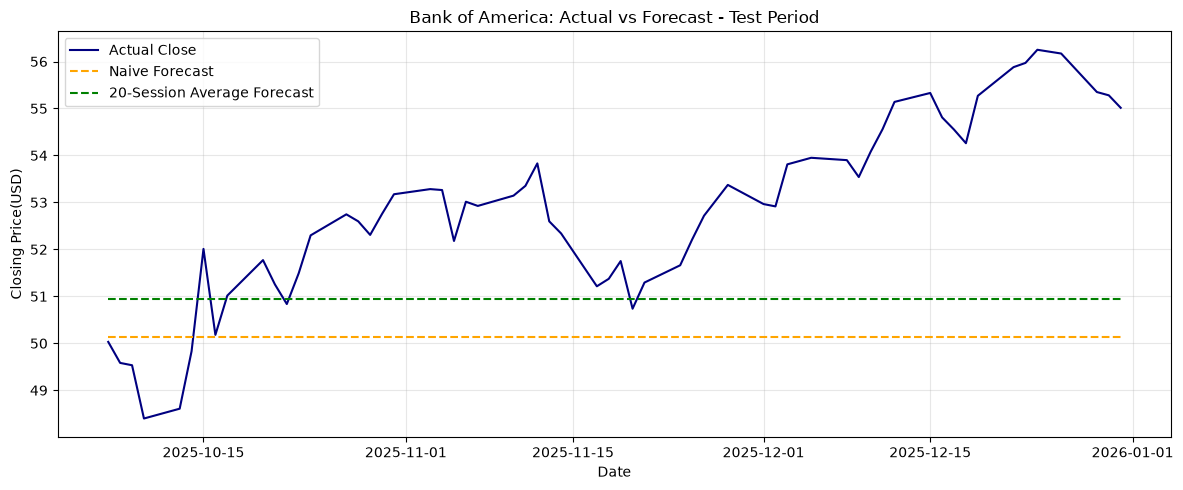

In [8]:
plt.figure(figsize=(12,5))

plt.plot(results["Date"], results["Close"], label = "Actual Close", color="navy")

plt.plot(results["Date"], results["Naive_Forecast"], label="Naive Forecast", color="orange", linestyle="--")

plt.plot(results["Date"], results["Mean20_Forecast"], label="20-Session Average Forecast", color="green", linestyle="--")

plt.title("Bank of America: Actual vs Forecast - Test Period")
plt.xlabel("Date")
plt.ylabel("Closing Price(USD)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

plt.savefig("Week2_01_Actual_vs_Forecast.png", dpi=300, bbox_inches= "tight")
plt.show()

In [9]:
naive_rmse = (
    (results["Close"] - results["Naive_Forecast"]) ** 2
).mean() ** 0.5

mean20_rmse = (
    (results["Close"] - results["Mean20_Forecast"]) ** 2
).mean() ** 0.5

comparison = pd.DataFrame({
    "Model": ["Naive", "20-Session Average"],
    "MAE_USD": [naive_mae, mean20_mae],
    "RMSE_USD": [naive_rmse, mean20_rmse]
})

comparison.round(2)

,Model,MAE_USD,RMSE_USD
0,Naive,2.86,3.28
1,20-Session Average,2.23,2.64


In [10]:
final_average = prices["Close"].tail(20).mean()

future_forecast = pd.DataFrame({
        "Trading_Session_Ahead": range(1, 61),
        "Forecast_Close_USD": final_average
     })

print("Forecast origin:", prices["Date"].max())
print("Forecast price (USD):", round(final_average, 2))

future_forecast.head(10)


Forecast origin: 2025-12-31 00:00:00-05:00
Forecast price (USD): 54.85


,Trading_Session_Ahead,Forecast_Close_USD
0,1,54.849718
1,2,54.849718
2,3,54.849718
3,4,54.849718
4,5,54.849718
5,6,54.849718
6,7,54.849718
7,8,54.849718
8,9,54.849718
9,10,54.849718


In [11]:
results.to_csv("Week2_Test_Results.csv", index=False)

comparison.to_csv("Week2_Model_Comparison.csv", index=False)

future_forecast.to_csv("Week2_Future_Forecast.csv", index=False)

print("All three CSV files saved successfully.")

All three CSV files saved successfully.


## Findings

| Model | MAE (USD) | RMSE (USD) |
|---|---:|---:|
| Naive | 2.86 | 3.28 |
| 20-Session Average | 2.23 | 2.64 |

- The 20-session average produced lower MAE and RMSE on this test period.
- Actual closing prices generally increased during the test period.
  Both fixed forecasts underestimated prices in its later portion.
- After evaluation, the average was recalculated using the final
  20 observations available on 31 December 2025.
- This produced a forecast of approximately $54.85 for each of the
  next 60 trading sessions.

## Limitations

- Evaluation covers one 60-session test period; performance may differ
  across other periods.
- Both methods produce constant forecasts and cannot capture future
  trends, daily fluctuations, or unexpected events.
- The models use closing prices only, without news, economic indicators,
  or company fundamentals.
- The $54.85 forecast is based on data ending 31 December 2025.
  It is not a live forecast, and its future accuracy has not been measured.
- Forecasts are point estimates; prediction intervals were not calculated.

## Conclusion

The 20-session average performed better than the naive benchmark
on the selected test period. It provides a simple, reproducible
forecast, but the chart shows its limitations when prices trend upward.
Further evaluation across multiple periods would be needed to assess
its reliability.